# Notebook 03 — Clustering & Recommendation

**Objective:** Apply PCA + K-Means to the processed feature matrix to
discover natural groupings in professional profiles, evaluate cluster
quality, interpret what each cluster represents, and demonstrate
profile recommendations using cosine similarity.

**Inputs:**
- `data/processed/X_processed.npy` — feature matrix from notebook 02
- `data/raw/profiles.csv` — original profiles for display layer

**Outputs:**
- `data/processed/cluster_labels.npy` — cluster assignment per profile
- `outputs/plots/` — PCA variance, elbow, silhouette, t-SNE figures
- `outputs/clusters/` — one CSV summary per cluster

In [45]:
import os
import sys

NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")

Project root : /Users/yugjain/Documents/ML_ASS/unsupervised-professional-matching


In [46]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score

from src.config import (
    RAW_DATA_PATH, PROCESSED_PATH, PLOTS_DIR,
    PCA_COMPONENTS, K_RANGE
)
from src.models.clustering import (
    run_kmeans_experiment,
    plot_elbow_and_silhouette,
    fit_final_kmeans,
    profile_clusters
)
from src.models.compatibility import recommend_profiles

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")
print("Imports complete")

Imports complete


In [47]:
X = np.load(PROCESSED_PATH)
print(f"Feature matrix shape : {X.shape}")

df_original = pd.read_csv(RAW_DATA_PATH)
print(f"Profiles loaded      : {len(df_original):,}")

vocab_path = os.path.join(PROJECT_ROOT, "data", "processed", "skill_vocab.txt")
with open(vocab_path) as f:
    skill_vocab = [line.strip() for line in f.readlines()]
print(f"Skill vocabulary     : {len(skill_vocab)} terms")

Feature matrix shape : (50000, 188)
Profiles loaded      : 50,000
Skill vocabulary     : 100 terms


## 1. Dimensionality Reduction — PCA

The feature matrix has ~200 dimensions. K-Means degrades in high
dimensions because distances become increasingly uniform (curse of
dimensionality). We apply StandardScaler to normalize all features
before PCA, then reduce to a fixed number of components that capture
the most important variance while avoiding overfitting.

t-SNE will be used separately for 2D visualisation only —
clustering is always performed on PCA output, never on t-SNE output.
t-SNE distorts global structure and is not suitable as a clustering input.

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions  : {X.shape[1]}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Variance retained    : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Compression ratio    : {X.shape[1]/X_pca.shape[1]:.1f}x")
print(f"\nPer-component variance:")
for i in range(len(pca.explained_variance_ratio_)):
    print(f"  PC{i+1:2d}: {pca.explained_variance_ratio_[i]*100:.2f}%")

Original dimensions  : 188
PCA dimensions       : 30
Variance retained    : 31.27%
Compression ratio    : 6.3x

Per-component variance:
  PC 1: 1.98%
  PC 2: 1.37%
  PC 3: 1.34%
  PC 4: 1.20%
  PC 5: 1.17%
  PC 6: 1.15%
  PC 7: 1.14%
  PC 8: 1.12%
  PC 9: 1.12%
  PC10: 1.12%
  PC11: 1.10%
  PC12: 1.09%
  PC13: 1.06%
  PC14: 1.05%
  PC15: 1.04%
  PC16: 1.03%
  PC17: 1.01%
  PC18: 1.00%
  PC19: 0.98%
  PC20: 0.97%
  PC21: 0.96%
  PC22: 0.94%
  PC23: 0.93%
  PC24: 0.92%
  PC25: 0.90%
  PC26: 0.86%
  PC27: 0.82%
  PC28: 0.79%
  PC29: 0.57%
  PC30: 0.56%


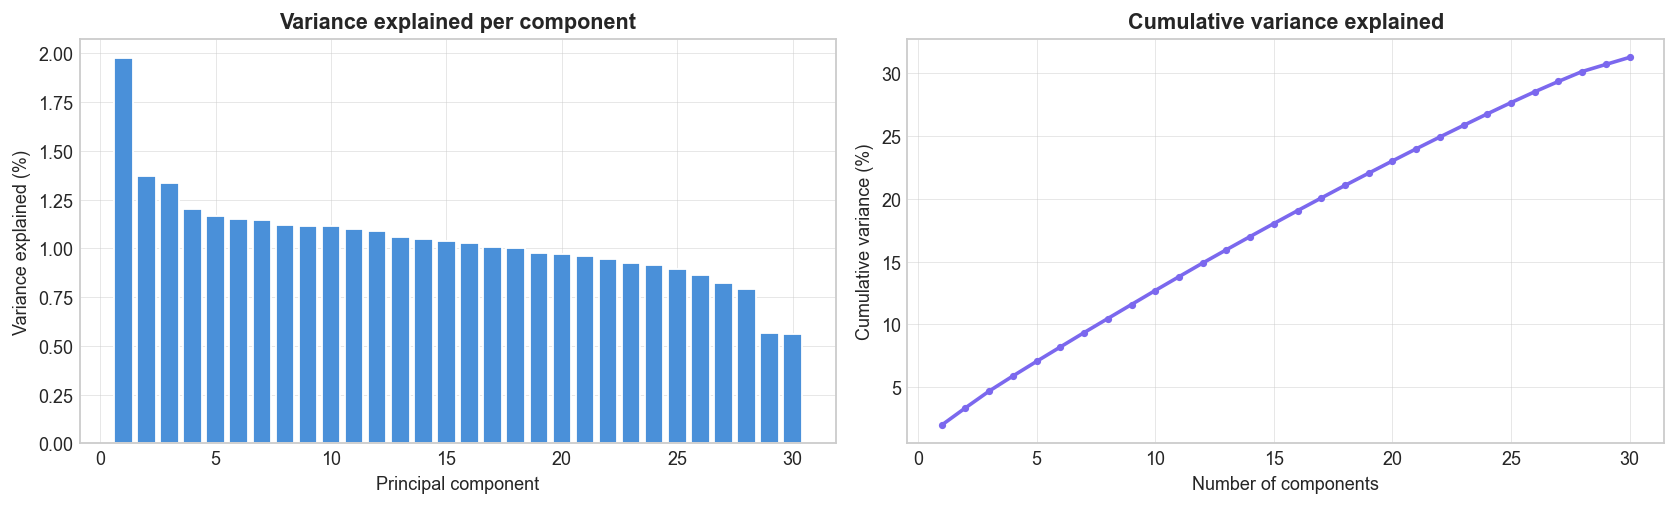

In [49]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color="#4A90D9", edgecolor="white")
axes[0].set_title("Variance explained per component",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")

axes[1].plot(range(1, len(cumulative_variance) + 1),
             cumulative_variance * 100,
             marker=".", color="#7B68EE", linewidth=2)
axes[1].set_title("Cumulative variance explained",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "09_pca_explained_variance.png"))
plt.show()

## 2. Choosing K — Elbow Method + Silhouette Score

Two complementary metrics are used to select K:

- **Inertia (elbow curve):** sum of squared distances from each point
  to its cluster centre. Lower is better, but always decreases with K.
  The "elbow" — where the rate of improvement slows — suggests a good K.

- **Silhouette score:** measures how similar a profile is to its own
  cluster versus neighbouring clusters. Ranges from -1 to 1.
  Higher is better. The peak identifies the most well-separated K.

Using both together avoids the weakness of either metric alone.

Running K-Means for K = 3 to 10...
  K= 3 | inertia=2,726,802 | silhouette=0.0471
  K= 4 | inertia=2,655,664 | silhouette=0.0517
  K= 5 | inertia=2,578,948 | silhouette=0.0571
  K= 6 | inertia=2,514,011 | silhouette=0.0632
  K= 7 | inertia=2,448,434 | silhouette=0.0663
  K= 8 | inertia=2,378,436 | silhouette=0.0820
  K= 9 | inertia=2,313,282 | silhouette=0.0871
  K=10 | inertia=2,240,086 | silhouette=0.1020


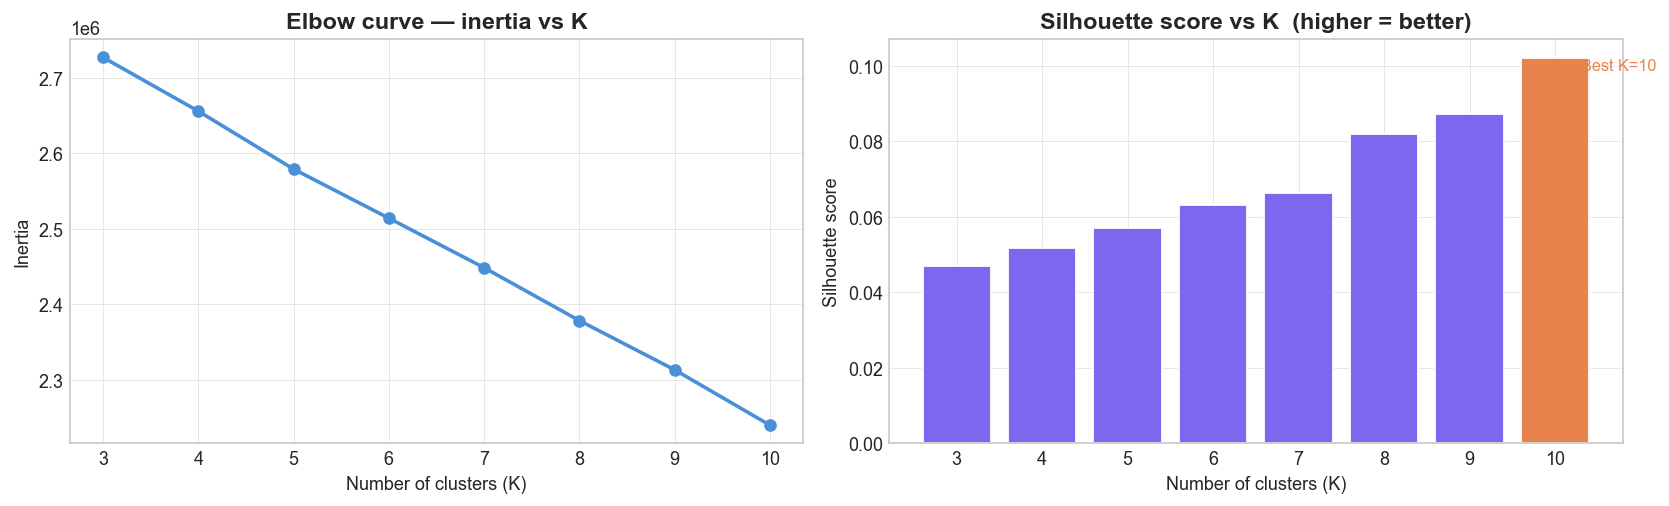


Best K by silhouette score: 10


In [56]:
results_df = run_kmeans_experiment(X_pca)
plot_elbow_and_silhouette(results_df)

In [51]:
BEST_K = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])

print(f"Selected K : {BEST_K}")
print(f"\nFull results table:")
print(results_df.to_string(index=False))

Selected K : 10

Full results table:
 k    inertia  silhouette
 3 2726802.00    0.047082
 4 2655663.50    0.051688
 5 2578947.75    0.057131
 6 2514011.25    0.063157
 7 2448434.25    0.066347
 8 2378436.00    0.081976
 9 2313282.50    0.087128
10 2240086.00    0.102003


## 3. Fit Final Model

In [52]:
labels = fit_final_kmeans(X_pca, BEST_K)

df_original["cluster"] = labels

labels_path = os.path.join(PROJECT_ROOT, "data", "processed",
                           "cluster_labels.npy")
np.save(labels_path, labels)
print(f"Cluster labels saved")

✓ Final K-Means fitted  (K=10)
  Cluster sizes:
    Cluster 0: 6,670 profiles (13.3%)
    Cluster 1: 3,374 profiles (6.7%)
    Cluster 2: 3,246 profiles (6.5%)
    Cluster 3: 3,328 profiles (6.7%)
    Cluster 4: 3,380 profiles (6.8%)
    Cluster 5: 3,513 profiles (7.0%)
    Cluster 6: 6,617 profiles (13.2%)
    Cluster 7: 9,625 profiles (19.2%)
    Cluster 8: 3,425 profiles (6.8%)
    Cluster 9: 6,822 profiles (13.6%)
Cluster labels saved


In [53]:
sil_score = silhouette_score(X_pca, labels, sample_size=5000,
                             random_state=42)
db_score  = davies_bouldin_score(X_pca, labels)

print("=" * 40)
print("Final model evaluation")
print("=" * 40)
print(f"K (clusters)           : {BEST_K}")
print(f"Silhouette score       : {sil_score:.4f}  (higher better, max 1.0)")
print(f"Davies-Bouldin index   : {db_score:.4f}  (lower better, min 0.0)")
print("=" * 40)

Final model evaluation
K (clusters)           : 10
Silhouette score       : 0.1020  (higher better, max 1.0)
Davies-Bouldin index   : 2.7088  (lower better, min 0.0)


## 4. Cluster Interpretation

For each cluster we compute the top skills, dominant industry, dominant
role, median experience, and seniority breakdown. This is what allows
clusters to be given human-readable names.

In [54]:
summary_df = profile_clusters(labels, df_original, skill_vocab)

print("Cluster summary:")
print(summary_df.to_string(index=False))

clusters_dir = os.path.join(PROJECT_ROOT, "outputs", "clusters")
for cluster_id in sorted(df_original["cluster"].unique()):
    subset = df_original[df_original["cluster"] == cluster_id]
    out_path = os.path.join(clusters_dir,
                            f"cluster_{cluster_id}_profiles.csv")
    subset.to_csv(out_path, index=False)

print(f"\nCluster CSVs saved")

Cluster summary:
 cluster  size  pct_of_total                                                                  top_skills  dominant_industry        dominant_role  median_exp top_seniority
       0  6670          13.3                                       docker, kubernetes, api, python, java Telecommunications       Technical Lead         5.2           mid
       1  3374           6.7 business analysis, stakeholder management, project management, aws, tableau         Consulting    Software Engineer         5.1           mid
       2  3246           6.5   python, curriculum development, e-learning, instructional design, node.js          Education  Engineering Manager         5.3           mid
       3  3328           6.7           spss, genomics, laboratory techniques, bioinformatics, statistics      Biotechnology  Engineering Manager         5.4           mid
       4  3380           6.8    healthcare analytics, data visualization, machine learning, python, spss         Healthcare     

## 5. t-SNE Visualisation

t-SNE projects the high-dimensional PCA space down to 2D for visual
inspection. Profiles that are close together in 2D were also close in
the original feature space.

Important: t-SNE is used for visualisation only. Clustering was
performed on PCA output.

In [ ]:
print("Running t-SNE — this takes 2-4 minutes on 50k profiles...")

tsne = TSNE(n_components=2, random_state=42, perplexity=40,
            n_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_pca)

palette = sns.color_palette("tab10", n_colors=BEST_K)

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(BEST_K):
    mask = labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[palette[cluster_id]],
        label=f"Cluster {cluster_id} (n={mask.sum():,})",
        alpha=0.4, s=4, linewidths=0
    )

ax.set_title("t-SNE projection coloured by cluster",
             fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "10_tsne_clusters.png"))
plt.show()

Running t-SNE — this takes 2-4 minutes on 50k profiles...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.002s...
[t-SNE] Computed neighbors for 50000 samples in 2.127s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000

## 6. Recommendation Demo

In [ ]:
QUERY_IDX = 0

query = df_original.iloc[QUERY_IDX]
print("=" * 55)
print("QUERY PROFILE")
print("=" * 55)
print(f"Name            : {query['name']}")
print(f"Role            : {query['current_role']}")
print(f"Company         : {query['current_company']}")
print(f"Industry        : {query['industry']}")
print(f"Seniority       : {query['seniority_level']}")
print(f"Experience      : {query['years_experience']} years")
print(f"Location        : {query['location']}")
print(f"Remote pref     : {query['remote_preference']}")
print(f"Skills          : {query['skills']}")
print(f"Goals           : {query['goals']}")
print(f"Needs           : {query['needs']}")
print(f"Can offer       : {query['can_offer']}")
print(f"Cluster         : {query['cluster']}")

In [ ]:
recommendations = recommend_profiles(
    query_idx   = QUERY_IDX,
    X           = X,
    labels      = labels,
    df_original = df_original,
    top_n       = 5
)

print("=" * 55)
print(f"TOP 5 SIMILAR PROFILES  (Cluster {labels[QUERY_IDX]})")
print("=" * 55)

for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
    print(f"\nRank {rank}  —  similarity: {row['similarity_score']:.4f}")
    print(f"  Name        : {row['name']}")
    print(f"  Role        : {row['current_role']}")
    print(f"  Company     : {row['current_company']}")
    print(f"  Industry    : {row['industry']}")
    print(f"  Seniority   : {row['seniority_level']}")
    print(f"  Experience  : {row['years_experience']} years")
    print(f"  Location    : {row['location']}")
    print(f"  Skills      : {row['skills']}")
    print(f"  Goals       : {row['goals']}")
    print(f"  Needs       : {row['needs']}")
    print(f"  Can offer   : {row['can_offer']}")
    print("-" * 55)

## 7. Results Summary